In [13]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [ ]:
# =========================
# NAČTENÍ VSTUPNÍCH SOUBORŮ
# =========================
# Načtení tří základních datasetů:
# - games: metadata o hrách
# - reviews: uživatelské recenze
# - ranking: žebříčky her podle různých kritérií
games = pd.read_csv("games.csv")
reviews = pd.read_csv("reviews.csv", low_memory=False)
ranking = pd.read_csv("ranking.csv")

# =========================
# POMOCNÉ FUNKCE
# =========================
def normalize_text(value):
    """
    Očistí textovou hodnotu:
    - odstraní nadbytečné mezery,
    - sjednotí vícenásobné mezery,
    - vrátí NaN, pokud vstupní hodnota chybí.
    """
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    value = re.sub(r"\s+", " ", value)
    return value


def normalize_key(value):
    """
    Vytvoří normalizovaný klíč pro spojování datasetů:
    - převede text na malá písmena,
    - odstraní nadbytečné mezery.
    """
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    value = re.sub(r"\s+", " ", value)
    return value


def extract_year(value):
    """
    Pokusí se z textového pole extrahovat rok ve formátu 19xx nebo 20xx.
    Pokud rok nenajde, vrátí NaN.
    """
    if pd.isna(value):
        return np.nan
    match = re.search(r"(19|20)\d{2}", str(value))
    return int(match.group()) if match else np.nan


def split_genres(value):
    """
    Rozdělí pole genres na seznam samostatných žánrů.
    Podporuje oddělovače jako čárka, středník, lomítko nebo svislá čára.
    """
    if pd.isna(value):
        return []
    parts = re.split(r"[,;/|]", str(value))
    parts = [p.strip() for p in parts if str(p).strip()]
    return list(dict.fromkeys(parts))


# =========================
# ČIŠTĚNÍ KOLEKCE GAMES
# =========================
games = games.copy()

# Přejmenování sloupců na jednotný tvar používaný v projektu
games = games.rename(columns={
    "name": "game_name",
    "short_description": "short_description",
    "long_description": "long_description",
    "genres": "genres",
    "minimum_system_requirement": "minimum_system_requirement",
    "recommend_system_requirement": "recommend_system_requirement",
    "release_date": "release_date",
    "developer": "developer",
    "publisher": "publisher",
    "overall_player_rating": "overall_player_rating",
    "number_of_reviews_from_purchased_people": "number_of_reviews_from_purchased_people",
    "number_of_english_reviews": "number_of_english_reviews",
    "link": "link"
})

# Očištění názvu hry a vytvoření normalizovaného klíče
games["game_name"] = games["game_name"].apply(normalize_text)
games["game_name_norm"] = games["game_name"].apply(normalize_key)

# Odstranění záznamů bez názvu hry a duplicit podle game_name_norm
games = games.dropna(subset=["game_name", "game_name_norm"])
games = games.drop_duplicates(subset=["game_name_norm"]).reset_index(drop=True)

# Textové sloupce, kde budou chybějící hodnoty nahrazeny textem "Unknown"
text_cols_games = [
    "short_description",
    "long_description",
    "genres",
    "minimum_system_requirement",
    "recommend_system_requirement",
    "release_date",
    "developer",
    "publisher",
    "overall_player_rating",
    "link"
]

for col in text_cols_games:
    if col in games.columns:
        games[col] = games[col].apply(normalize_text).fillna("Unknown")

# Numerické sloupce převedené na číselný typ
numeric_cols_games = [
    "number_of_reviews_from_purchased_people",
    "number_of_english_reviews"
]

for col in numeric_cols_games:
    if col in games.columns:
        games[col] = pd.to_numeric(games[col], errors="coerce")

# Odvozené atributy:
# - release_year: rok vydání
# - genres_list: seznam žánrů
# - has_unknown_meta: příznak neúplných metadat
games["release_year"] = games["release_date"].apply(extract_year)
games["genres_list"] = games["genres"].apply(split_genres)
games["has_unknown_meta"] = (
    (games["short_description"] == "Unknown") |
    (games["long_description"] == "Unknown") |
    (games["developer"] == "Unknown") |
    (games["publisher"] == "Unknown")
)

# =========================
# ČIŠTĚNÍ KOLEKCE REVIEWS
# =========================
reviews = reviews.copy()

# Přejmenování sloupců do jednotného schématu
reviews = reviews.rename(columns={
    "review": "review",
    "hours_played": "hours_played",
    "helpful": "helpful",
    "funny": "funny",
    "recommendation": "recommendation",
    "date": "review_date",
    "game_name": "game_name",
    "username": "username"
})

# Očištění názvu hry a vytvoření normalizovaného klíče
reviews["game_name"] = reviews["game_name"].apply(normalize_text)
reviews["game_name_norm"] = reviews["game_name"].apply(normalize_key)

# Odstranění recenzí bez textového obsahu
reviews["review"] = reviews["review"].fillna("").astype(str).str.strip()
reviews = reviews[reviews["review"] != ""].copy()

# Doplnění chybějících uživatelů a doporučení
reviews["username"] = reviews["username"].fillna("unknown_user").apply(normalize_text)
reviews["recommendation"] = (
    reviews["recommendation"]
    .fillna("unknown")
    .astype(str)
    .str.strip()
    .str.lower()
)

# Převod vybraných sloupců na numerické typy
for col in ["hours_played", "helpful", "funny"]:
    if col in reviews.columns:
        reviews[col] = pd.to_numeric(reviews[col], errors="coerce")

# Očištění data a jeho převod na datetime
reviews["review_date"] = reviews["review_date"].apply(normalize_text)
reviews["review_dt"] = pd.to_datetime(
    reviews["review_date"],
    errors="coerce",
    format="mixed"
)

# Odvozené atributy z data a recenze
reviews["review_year"] = reviews["review_dt"].dt.year
reviews["review_month"] = reviews["review_dt"].dt.month
reviews["is_recommended"] = (reviews["recommendation"] == "recommended").astype(int)
reviews["review_length"] = reviews["review"].astype(str).str.len()

# Odstranění záznamů bez názvu hry a duplicit
reviews = reviews.dropna(subset=["game_name", "game_name_norm"])
reviews = reviews.drop_duplicates().reset_index(drop=True)

# Dataset reviews je velmi rozsáhlý, proto je omezen na 20 000 záznamů.
# Tato velikost je dostatečná pro splnění zadání a zároveň je praktičtější
# pro vývoj, testování i obhajobu projektu.
if len(reviews) > 20000:
    reviews = reviews.sample(n=20000, random_state=42).reset_index(drop=True)

# =========================
# ČIŠTĚNÍ KOLEKCE RANKING
# =========================
ranking = ranking.copy()

# Přejmenování sloupců do jednotného schématu
ranking = ranking.rename(columns={
    "game_name": "game_name",
    "genre": "genre",
    "rank_type": "rank_type",
    "rank": "rank"
})

# Očištění textových polí a vytvoření normalizovaného klíče
ranking["game_name"] = ranking["game_name"].apply(normalize_text)
ranking["game_name_norm"] = ranking["game_name"].apply(normalize_key)
ranking["genre"] = ranking["genre"].fillna("Unknown").apply(normalize_text)
ranking["rank_type"] = ranking["rank_type"].fillna("Unknown").astype(str).str.strip().str.lower()

# Převod rank na číselný typ
ranking["rank"] = pd.to_numeric(ranking["rank"], errors="coerce")

# Odstranění neplatných záznamů a duplicit
ranking = ranking.dropna(subset=["game_name", "game_name_norm", "rank"]).reset_index(drop=True)
ranking = ranking.drop_duplicates().reset_index(drop=True)

# =========================
# PONECHÁNÍ POUZE SPOLEČNÉHO PRŮNIKU
# =========================
# Pro následné spojování kolekcí je vhodné ponechat pouze hry,
# které existují současně ve všech třech datasetech.
games_keys = set(games["game_name_norm"])
reviews_keys = set(reviews["game_name_norm"])
ranking_keys = set(ranking["game_name_norm"])

common_keys = games_keys & reviews_keys & ranking_keys

games_common = games[games["game_name_norm"].isin(common_keys)].copy()
reviews_common = reviews[reviews["game_name_norm"].isin(common_keys)].copy()
ranking_common = ranking[ranking["game_name_norm"].isin(common_keys)].copy()

print("=== INTERSECTIONS ===")
print("games ∩ reviews:", len(games_keys & reviews_keys))
print("games ∩ ranking:", len(games_keys & ranking_keys))
print("reviews ∩ ranking:", len(reviews_keys & ranking_keys))
print("common in all 3:", len(common_keys))

# =========================
# ZÁKLADNÍ SOUHRN KVALITY DAT
# =========================
print("\n=== COUNTS BEFORE FILTER ===")
print("games:", len(games))
print("reviews:", len(reviews))
print("ranking:", len(ranking))

print("\n=== COUNTS COMMON ONLY ===")
print("games_common:", len(games_common))
print("reviews_common:", len(reviews_common))
print("ranking_common:", len(ranking_common))

print("\n=== MISSING VALUES ===")
print("games missing:\n", games_common.isna().sum())
print("reviews missing:\n", reviews_common.isna().sum())
print("ranking missing:\n", ranking_common.isna().sum())

# =========================
# ULOŽENÍ JSON SOUBORŮ PRO MONGODB
# =========================
# Výsledná data jsou exportována ve formátu JSON Lines,
# kde každý řádek odpovídá jednomu dokumentu.
games_common.to_json(
    "games.json",
    orient="records",
    lines=True,
    force_ascii=False,
    date_format="iso"
)

reviews_common.to_json(
    "reviews.json",
    orient="records",
    lines=True,
    force_ascii=False,
    date_format="iso"
)

ranking_common.to_json(
    "ranking.json",
    orient="records",
    lines=True,
    force_ascii=False,
    date_format="iso"
)

# =========================
# ULOŽENÍ VYČIŠTĚNÝCH CSV SOUBORŮ
# =========================
games_common.to_csv("games_clean.csv", index=False)
reviews_common.to_csv("reviews_clean.csv", index=False)
ranking_common.to_csv("ranking_clean.csv", index=False)

print("\n=== FINAL COUNTS SAVED ===")
print("games:", len(games_common))
print("reviews:", len(reviews_common))
print("ranking:", len(ranking_common))

=== INTERSECTIONS ===
games ∩ reviews: 226
games ∩ ranking: 290
reviews ∩ ranking: 226
common in all 3: 226

=== COUNTS BEFORE FILTER ===
games: 290
reviews: 20000
ranking: 672

=== COUNTS COMMON ONLY ===
games_common: 226
reviews_common: 18686
ranking_common: 498

=== MISSING VALUES ===
games missing:
 game_name                                    0
short_description                            0
long_description                             0
genres                                       0
minimum_system_requirement                   0
recommend_system_requirement                 0
release_date                                 0
developer                                    0
publisher                                    0
overall_player_rating                        0
number_of_reviews_from_purchased_people    226
number_of_english_reviews                  202
link                                         0
game_name_norm                               0
release_year                         

In [14]:
# Prázdné hodnoty
print("Missing values in games:")
print(games.isnull().sum())

print("\nMissing values in reviews:")
print(reviews.isnull().sum())

print("\nMissing values in ranking:")
print(ranking.isnull().sum())

print((games.isnull().sum() / len(games) * 100).round(2))

Missing values in games:
game_name                                    0
short_description                            0
long_description                             0
genres                                       0
minimum_system_requirement                   0
recommend_system_requirement                 0
release_date                                 0
developer                                    0
publisher                                    0
overall_player_rating                        0
number_of_reviews_from_purchased_people    290
number_of_english_reviews                  253
link                                         0
game_name_norm                               0
release_year                                 0
genres_list                                  0
has_unknown_meta                             0
dtype: int64

Missing values in reviews:
review               0
hours_played      1436
helpful             50
funny               19
recommendation       0
review_date         

In [15]:
# Statistiky
print(games.describe(include="all"))
print(reviews.describe(include="all"))
print(ranking.describe(include="all"))

                 game_name short_description  \
count                  290               290   
unique                 290               278   
top     Black Myth: Wukong           Unknown   
freq                     1                13   
mean                   NaN               NaN   
std                    NaN               NaN   
min                    NaN               NaN   
25%                    NaN               NaN   
50%                    NaN               NaN   
75%                    NaN               NaN   
max                    NaN               NaN   

                                         long_description  \
count                                                 290   
unique                                                290   
top     About This Game Black Myth: Wukong is an actio...   
freq                                                    1   
mean                                                  NaN   
std                                                   NaN

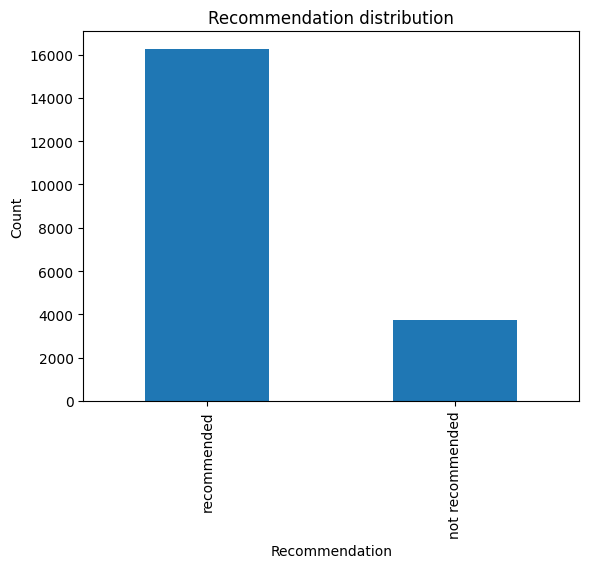

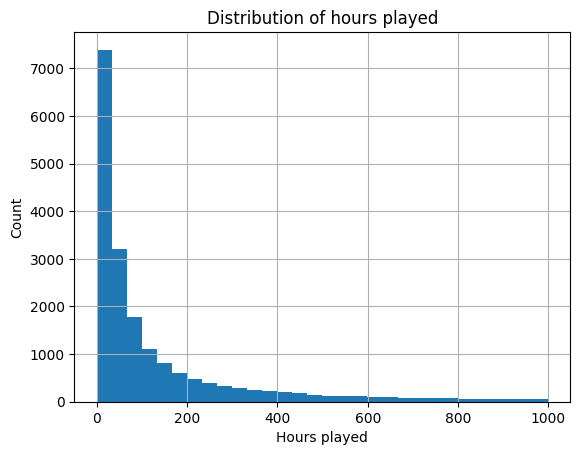

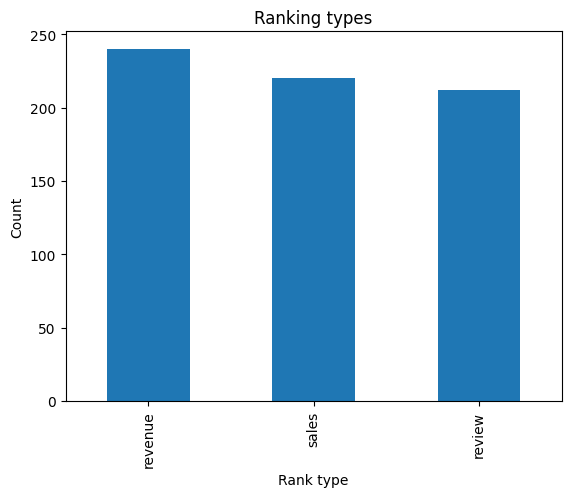

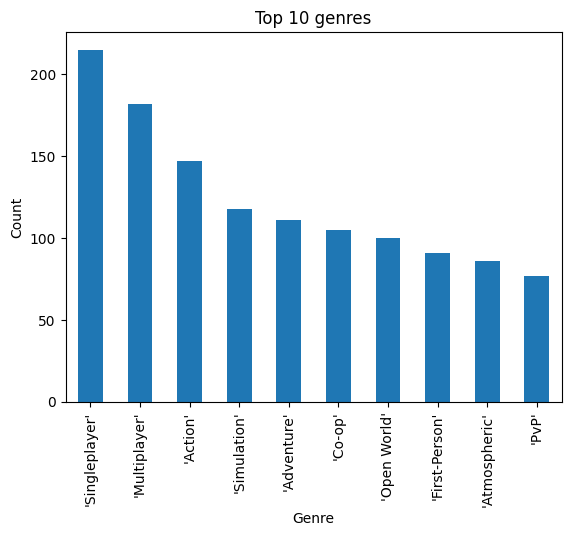

In [20]:
# Grafy
reviews["recommendation"].value_counts().plot(kind="bar")
plt.title("Recommendation distribution")
plt.xlabel("Recommendation")
plt.ylabel("Count")
plt.show()

reviews["hours_played"].dropna().hist(bins=30)
plt.title("Distribution of hours played")
plt.xlabel("Hours played")
plt.ylabel("Count")
plt.show()

ranking["rank_type"].value_counts().plot(kind="bar")
plt.title("Ranking types")
plt.xlabel("Rank type")
plt.ylabel("Count")
plt.show()

genres_exploded = games["genres_list"].explode()
genres_exploded.value_counts().head(10).plot(kind="bar")
plt.title("Top 10 genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()